# 🧠 Modelos para generación de Video 🖼️

## 📍¿Para qué sirven los modelos de generación de video?

Los **modelos de generación de video** permiten **crear clips animados a partir de texto o imágenes** utilizando inteligencia artificial.  
Estos modelos combinan visión por computadora y redes neuronales para producir secuencias coherentes de imágenes que forman un video.

### 🎯 Usos comunes:
- 🎥 **Producción de contenido creativo**  
- 🧪 **Simulaciones y visualizaciones científicas**  
- 📈 **Marketing automatizado y generación de anuncios**  
- 🎨 **Creación de prototipos visuales y concept art**

### 🤖 Ejemplos de modelos populares:
- **ModelScope Video Generation**  
- **ZeroScope V2**  
- **AnimateDiff**

In [1]:
from diffusers import StableVideoDiffusionPipeline
from diffusers.utils import load_image
import torch, imageio

# Cargar el modelo más liviano de video
pipe = StableVideoDiffusionPipeline.from_pretrained(
    "stabilityai/stable-video-diffusion-img2vid",
    torch_dtype=torch.float16,
    variant="fp16"
).to("cuda" if torch.cuda.is_available() else "cpu")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/986 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/518 [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.fp16.safeten(…):   0%|          | 0.00/196M [00:00<?, ?B/s]

image_encoder/model.fp16.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

unet/diffusion_pytorch_model.fp16.safete(…):   0%|          | 0.00/3.05G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


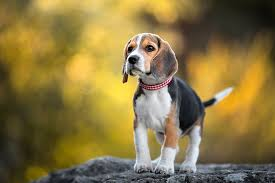

In [3]:
# Imagen base (puedes reemplazarla por una URL o tu propia imagen)
from PIL import Image

image_path = "/content/perro.jpeg"
try:
    image = Image.open(image_path).convert("RGB")
    display(image)
except FileNotFoundError:
    print(f"Error: The image file was not found at {image_path}. Please make sure the image is uploaded to your Colab session.")

In [5]:
# Generar frames del video
generator = torch.manual_seed(42)
frames = pipe(image, decode_chunk_size=1, generator=generator, num_frames=15).frames[0]

# Guardar el video resultante
output_path = "/content/svd_output.mp4"
imageio.mimsave(output_path, frames, fps=8)
print("✅ Video generado:", output_path)

from IPython.display import Video
Video(output_path, embed=True)

  0%|          | 0/25 [00:00<?, ?it/s]

✅ Video generado: /content/svd_output.mp4
